<a href="https://colab.research.google.com/github/danisxde/x5_ml/blob/main/RTO_forecast_march2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏪 Прогноз РТО — март 2025

**Пайплайн:** Препроцессинг → Feature Engineering → Ансамбль (LightGBM + CatBoost + XGBoost) → Предсказание март 2025


## 0. Импорты и настройки

In [1]:
!pip install catboost optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool
from scipy.optimize import minimize

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)

print("Библиотеки загружены ✓")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.4 MB/s eta 0:00:00
Библиотеки загружены ✓


## 1. Загрузка данных

In [2]:
from google.colab import drive
drive.mount('/content/drive')
df_raw = pd.read_csv('/content/drive/MyDrive/train_2.csv')

Mounted at /content/drive


## 2. Удаление выбросов РТО

Удаляем записи за пределами [1%, 99%] по РТО в обучающей выборке.
Март 2025 (целевой период) из фильтрации исключается.


In [3]:
TARGET_YEAR, TARGET_MONTH = 2025, 3

# Целевой период строим из февраля 2025
feb_2025 = df_raw[(df_raw['Год'] == 2025) & (df_raw['Месяц'] == 2)].copy()
print(f"Февраль 2025 — строк: {len(feb_2025)}")

df_target_raw = feb_2025.copy()
df_target_raw['Год']  = 2025
df_target_raw['Месяц'] = 3
df_target_raw['РТО']  = np.nan

# Обучение — всё кроме февраля-марта 2025
df_train_raw = df_raw[
    ~((df_raw['Год'] == 2025) & (df_raw['Месяц'] >= 2))
].copy()

# Удаляем выбросы РТО [1%, 99%] только по обучению
q_lo = df_train_raw['РТО'].quantile(0.01)
q_hi = df_train_raw['РТО'].quantile(0.99)
df_train_raw = df_train_raw[
    (df_train_raw['РТО'] >= q_lo) & (df_train_raw['РТО'] <= q_hi)
].copy()

print(f"Обучение после фильтрации: {df_train_raw.shape}")
print(f"Целевой период (март 2025): {df_target_raw.shape}")
print(f"РТО cutoff: [{q_lo:,.0f} ; {q_hi:,.0f}]")

Февраль 2025 — строк: 18657
Обучение после фильтрации: (457095, 24)
Целевой период (март 2025): (18657, 24)
РТО cutoff: [30,783,502 ; 264,865,544]


In [4]:
def clean_col_names(df):
    df = df.copy()
    df.columns = [re.sub(r'[^A-Za-z0-9_а-яА-ЯёЁ]', '_', col) for col in df.columns]
    return df

## 3. Feature Engineering

### Что добавляем:
- `log_population`, `log_households` — логарифм численности / домохозяйств
- `log_traffic_auto`, `log_traffic_foot` — логарифм трафика
- `cancels_lag1` — среднее кол-во отмен за **прошлый** месяц (защита от leakage)
- `is_december` — флаг декабря (пик РТО)
- `is_jan_feb` — флаг провала в начале года
- `kassi_per_area` — количество касс как прокси эффективности (нормируем на площадь через OE)
- `month_sin`, `month_cos` — циклическое кодирование месяца
- `target_enc_region` — target encoding региона (fold-wise, без leakage)
- `target_enc_city`   — target encoding населённого пункта


In [5]:
def add_rto_lag(df, rto_hist, months_back, col_name):
    """Добавляет лаг РТО на months_back месяцев назад."""
    tmp = rto_hist.copy()
    tmp['Месяц_join'] = tmp['Месяц'] + months_back
    tmp['Год_join']   = tmp['Год']
    tmp.loc[tmp['Месяц_join'] > 12, 'Год_join']   += 1
    tmp.loc[tmp['Месяц_join'] > 12, 'Месяц_join'] -= 12
    return df.merge(
        tmp[['new_id', 'Год_join', 'Месяц_join', 'РТО']].rename(
            columns={'РТО': col_name,
                     'Год_join': 'Год',
                     'Месяц_join': 'Месяц'}),
        on=['new_id', 'Год', 'Месяц'], how='left')


def feature_engineering(df, lag_source, is_train=True):
    d = df.copy()

    # ── Логарифмы ──
    d['log_численность_населения']   = np.log1p(d['Численность населения'])
    d['log_количество_домохозяйств'] = np.log1p(d['Количество домохозяйств'])
    d['log_трафик_авто']             = np.log1p(d['Трафик авто, в час'])
    d['log_трафик_пеший']            = np.log1p(d['Трафик пеший, в час'])

    # ── Clip отмен ──
    cancels_clip = lag_source['Среднее количество отмен'].quantile(0.99)
    d['cancels_clipped'] = d['Среднее количество отмен'].clip(upper=cancels_clip)

    # ── Lag отмен ──
    lag_map = (lag_source.groupby(['new_id', 'Год', 'Месяц'])['Среднее количество отмен']
               .mean().reset_index()
               .rename(columns={'Среднее количество отмен': 'cancels_lag1'}))
    lag_map['Год_join']   = lag_map['Год']
    lag_map['Месяц_join'] = lag_map['Месяц'] + 1
    lag_map.loc[lag_map['Месяц_join'] > 12, 'Год_join']   += 1
    lag_map.loc[lag_map['Месяц_join'] > 12, 'Месяц_join']  = 1
    d = d.merge(lag_map[['new_id', 'Год_join', 'Месяц_join', 'cancels_lag1']],
                left_on=['new_id', 'Год', 'Месяц'],
                right_on=['new_id', 'Год_join', 'Месяц_join'],
                how='left').drop(columns=['Год_join', 'Месяц_join'])
    d['cancels_lag1'] = d['cancels_lag1'].fillna(
        d.groupby('new_id')['cancels_clipped'].transform('median'))

    # ── Лаги РТО (ключевое новшество v2) ──
    rto_hist = (lag_source.groupby(['new_id', 'Год', 'Месяц'])['РТО']
                .mean().reset_index())

    d = add_rto_lag(d, rto_hist, 1, 'rto_lag1')
    d = add_rto_lag(d, rto_hist, 2, 'rto_lag2')
    d = add_rto_lag(d, rto_hist, 3, 'rto_lag3')
    d = add_rto_lag(d, rto_hist, 12, 'rto_lag12')

    # Скользящее среднее 3 месяца
    d['rto_roll3'] = d[['rto_lag1', 'rto_lag2', 'rto_lag3']].mean(axis=1)

    # Логарифмы лагов
    for col in ['rto_lag1', 'rto_lag2', 'rto_lag12', 'rto_roll3']:
        d[f'log_{col}'] = np.log1p(d[col].clip(lower=0))

    # Заполнение пропусков в лагах медианой по магазину
    for col in ['rto_lag1', 'rto_lag2', 'rto_lag3', 'rto_lag12',
                'rto_roll3', 'log_rto_lag1', 'log_rto_lag2',
                'log_rto_lag12', 'log_rto_roll3']:
        if col in d.columns:
            global_med = lag_source['РТО'].median() if 'log' not in col else np.log1p(lag_source['РТО'].median())
            d[col] = d[col].fillna(global_med)

    # ── YoY-рост ──
    d['rto_yoy_growth'] = d['rto_lag1'] / (d['rto_lag12'].clip(lower=1))

    # ── Отклонение от медианы региона ──
    region_median = lag_source.groupby('Регион')['РТО'].median()
    d['rto_vs_region'] = d['rto_lag1'] / d['Регион'].map(region_median).clip(lower=1)

    # ── Сезонность ──
    d['is_december'] = (d['Месяц'] == 12).astype(int)
    d['is_jan_feb']  = (d['Месяц'].isin([1, 2])).astype(int)
    d['month_sin']   = np.sin(2 * np.pi * d['Месяц'] / 12)
    d['month_cos']   = np.cos(2 * np.pi * d['Месяц'] / 12)

    # ── Структурные признаки магазина ──
    area_map = {'Маленький': 1, 'Средний': 2, 'Большой': 3, 'Очень большой': 4}
    age_map  = {'Новый': 0, 'Средний по возрасту': 1, 'Открыт давно': 2}
    d['area_ord']       = d['Торговая площадь, категориальный'].map(area_map)
    d['age_ord']        = d['Дата открытия, категориальный'].map(age_map)
    d['kassi_per_area'] = d['Количество касс'] / d['area_ord'].clip(lower=1)

    return d


df_fe = feature_engineering(df_train_raw, lag_source=df_train_raw, is_train=True)
print(f"После FE: {df_fe.shape[1]} признаков")

После FE: 48 признаков


## 4. Target Encoding (fold-wise, без leakage)

Кодируем `Регион` и `Населённый пункт` средним log(РТО) по фолдам —
так энкодер не видит целевую переменную текущей строки.


In [6]:
def target_encode_fit(df, col, target, n_splits=5, smoothing=20):
    global_mean = df[target].mean()
    encoded = pd.Series(index=df.index, dtype=float)
    # Fold-wise по времени
    tscv_te = TimeSeriesSplit(n_splits=n_splits)
    for tr_idx, val_idx in tscv_te.split(df):
        tr = df.iloc[tr_idx]
        gs = tr.groupby(col)[target].agg(['mean', 'count'])
        smooth = (gs['count'] * gs['mean'] + smoothing * global_mean) / (gs['count'] + smoothing)
        encoded.iloc[val_idx] = df.iloc[val_idx][col].map(smooth).fillna(global_mean)
    gs_full = df.groupby(col)[target].agg(['mean', 'count'])
    group_means = (gs_full['count'] * gs_full['mean'] + smoothing * global_mean) / (gs_full['count'] + smoothing)
    return encoded, global_mean, group_means

def target_encode_transform(series, group_means, global_mean):
    return series.map(group_means).fillna(global_mean)

df_fe['log_rto'] = np.log1p(df_fe['РТО'])

df_fe['te_region'], te_region_mean, te_region_groups = target_encode_fit(
    df_fe.sort_values(['Год', 'Месяц']), 'Регион', 'log_rto')
df_fe['te_city'], te_city_mean, te_city_groups = target_encode_fit(
    df_fe.sort_values(['Год', 'Месяц']), 'Населенный пункт', 'log_rto')

print("Target encoding ✓")

Target encoding ✓


## 5. Список признаков для модели

In [7]:
FEATURES_RAW = [
    # Время
    'Год', 'Месяц', 'month_sin', 'month_cos', 'is_december', 'is_jan_feb',

    # Лаги РТО — главное новшество
    'log_rto_lag1', 'log_rto_lag2', 'log_rto_lag12', 'log_rto_roll3',
    'rto_yoy_growth', 'rto_vs_region',

    # Транзакционные
    'Среднее количество промо товаров в чеке',
    'Среднее количество товаров в чеке',
    'cancels_clipped', 'cancels_lag1',
    'Рабочие часы в день',

    # Магазин
    'area_ord', 'age_ord', 'kassi_per_area', 'Количество касс',
    'Флаг алкогольной лицензии',

    # Локация (target-encoded)
    'te_region', 'te_city',

    # Демография
    'log_численность_населения', 'log_количество_домохозяйств',
    'log_трафик_авто', 'log_трафик_пеший',

    # Инфраструктура
    'Маркетплейсы, доставки, постаматы (100 м)',
    'Медицинские уч. и аптеки (300 м)',
    'Школы (300 м)', 'Остановки (300 м)',
    'Продуктовые магазины (500 м)', 'Пятерочки (500 м)',
]

# Сортируем по времени для TimeSeriesSplit
df_fe = df_fe.sort_values(['Год', 'Месяц', 'new_id']).reset_index(drop=True)
df_fe = clean_col_names(df_fe)

# Обновляем имена признаков после очистки
col_map = {re.sub(r'[^A-Za-z0-9_а-яА-ЯёЁ]', '_', c): c for c in FEATURES_RAW}
FEATURES = [re.sub(r'[^A-Za-z0-9_а-яА-ЯёЁ]', '_', f) for f in FEATURES_RAW]
FEATURES = [f for f in FEATURES if f in df_fe.columns]

TARGET = 'log_rto'
df_fe_clean = df_fe[df_fe['Год'] >= 2024].reset_index(drop=True)

X = df_fe_clean[FEATURES]
y = df_fe_clean[TARGET]

print(f"Признаков: {len(FEATURES)}")
print(f"X: {X.shape}, y: {y.shape}")

missing = [f for f in [re.sub(r'[^A-Za-z0-9_а-яА-ЯёЁ]', '_', f) for f in FEATURES_RAW]
           if f not in df_fe.columns]
if missing:
    print(f"⚠️ Не найдены: {missing}")

Признаков: 34
X: (238161, 34), y: (238161,)


In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238161 entries, 0 to 238160
Data columns (total 34 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   Год                                        238161 non-null  int64  
 1   Месяц                                      238161 non-null  int64  
 2   month_sin                                  238161 non-null  float64
 3   month_cos                                  238161 non-null  float64
 4   is_december                                238161 non-null  int64  
 5   is_jan_feb                                 238161 non-null  int64  
 6   log_rto_lag1                               238161 non-null  float64
 7   log_rto_lag2                               238161 non-null  float64
 8   log_rto_lag12                              238161 non-null  float64
 9   log_rto_roll3                              238161 non-null  float64
 10  rto_yoy_

## 6. Вспомогательные функции оценки

In [9]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

def eval_metrics(y_true_log, y_pred_log, label=''):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label:25s}  MAE={mae/1e6:.2f}M  RMSE={rmse/1e6:.2f}M  MAPE={mape:.2f}%  R²={r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'r2': r2}

## 7. Модель 1 — LightGBM

In [10]:
# Для Optuna — сэмплируем подвыборку и уменьшаем деревья
OPTUNA_SAMPLE = 100_000  # строк достаточно для подбора гиперпараметров
idx_sample = np.random.choice(len(X), size=min(OPTUNA_SAMPLE, len(X)), replace=False)
idx_sample = np.sort(idx_sample)
X_opt = X.iloc[idx_sample].reset_index(drop=True)
y_opt = y.iloc[idx_sample].reset_index(drop=True)

tscv_opt = TimeSeriesSplit(n_splits=3)  # 3 фолда вместо 5

def lgb_objective(trial):
    params = dict(
        objective='regression',
        metric='rmse',
        learning_rate=trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
        num_leaves=trial.suggest_int('num_leaves', 63, 255),
        min_child_samples=trial.suggest_int('min_child_samples', 20, 100),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        n_estimators=1000,   # ← было 5000, early stopping всё равно остановит раньше
        random_state=SEED,
        verbose=-1,
    )
    scores = []
    for tr_idx, val_idx in tscv_opt.split(X_opt):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_opt.iloc[tr_idx], y_opt.iloc[tr_idx],
              eval_set=[(X_opt.iloc[val_idx], y_opt.iloc[val_idx])],
              callbacks=[lgb.early_stopping(30, verbose=False)])
        scores.append(np.sqrt(mean_squared_error(y_opt.iloc[val_idx],
                                                  m.predict(X_opt.iloc[val_idx]))))
    return np.mean(scores)

study_lgb = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_objective, n_trials=20, show_progress_bar=True)

  0%|          | 0/20 [00:00<?, ?it/s]

In [11]:
best_lgb_params = study_lgb.best_params
best_lgb_params.update({'objective': 'regression', 'metric': 'rmse',
                          'n_estimators': 5000, # Increased n_estimators for final training
                          'random_state': SEED})

lgb_oof    = np.zeros(len(X))
lgb_models = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**best_lgb_params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(100, verbose=False),
                         lgb.log_evaluation(500)])
    lgb_oof[val_idx] = model.predict(X_val)
    lgb_models.append(model)
    eval_metrics(y_val.values, lgb_oof[val_idx], f'LGB fold {fold}')

print("\n=== LightGBM OOF ===")
eval_metrics(y.values, lgb_oof, 'LightGBM')

[500]	valid_0's rmse: 0.0816206
LGB fold 1                 MAE=4.74M  RMSE=7.72M  MAPE=5.30%  R²=0.9681
[500]	valid_0's rmse: 0.0837223
[1000]	valid_0's rmse: 0.0819373
[1500]	valid_0's rmse: 0.0813912
[2000]	valid_0's rmse: 0.081135
[2500]	valid_0's rmse: 0.081021
LGB fold 2                 MAE=5.63M  RMSE=8.82M  MAPE=6.07%  R²=0.9600
[500]	valid_0's rmse: 0.0920348
[1000]	valid_0's rmse: 0.0910476
[1500]	valid_0's rmse: 0.0903937
[2000]	valid_0's rmse: 0.0900147
[2500]	valid_0's rmse: 0.0897999
[3000]	valid_0's rmse: 0.0896132
LGB fold 3                 MAE=6.05M  RMSE=9.26M  MAPE=6.75%  R²=0.9547
[500]	valid_0's rmse: 0.0812242
[1000]	valid_0's rmse: 0.0798224
[1500]	valid_0's rmse: 0.0791819
[2000]	valid_0's rmse: 0.0787689
[2500]	valid_0's rmse: 0.0784894
[3000]	valid_0's rmse: 0.0782573
LGB fold 4                 MAE=5.27M  RMSE=7.93M  MAPE=5.71%  R²=0.9659
LGB fold 5                 MAE=8.12M  RMSE=11.54M  MAPE=8.15%  R²=0.9343

=== LightGBM OOF ===
LightGBM                   MA

{'mae': 18810049.42664995,
 'rmse': np.float64(38718574.528664395),
 'mape': np.float64(21.997012078408876),
 'r2': 0.20944985308497566}

## 8. Модель 2 — XGBoost

In [12]:
def xgb_objective(trial):
    params = dict(
        objective='reg:squarederror',
        eval_metric='rmse',
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        max_depth=trial.suggest_int('max_depth', 5, 10),
        min_child_weight=trial.suggest_int('min_child_weight', 5, 50),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        n_estimators=1000,
        early_stopping_rounds=50,
        random_state=SEED,
        tree_method='hist',
    )
    scores = []
    for tr_idx, val_idx in tscv.split(X_opt):
        m = xgb.XGBRegressor(**params)
        m.fit(X_opt.iloc[tr_idx], y_opt.iloc[tr_idx],
              eval_set=[(X_opt.iloc[val_idx], y_opt.iloc[val_idx])],
              verbose=False)
        scores.append(np.sqrt(mean_squared_error(y_opt.iloc[val_idx], m.predict(X_opt.iloc[val_idx]))))
    return np.mean(scores)

study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=15, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({'objective': 'reg:squarederror', 'eval_metric': 'rmse',
                          'n_estimators': 5000, 'early_stopping_rounds': 100,
                          'random_state': SEED, 'tree_method': 'hist'})
print(f"\nЛучший RMSE XGB: {study_xgb.best_value:.5f}")
print(f"Параметры: {best_xgb_params}")

  0%|          | 0/15 [00:00<?, ?it/s]


Лучший RMSE XGB: 0.09175
Параметры: {'learning_rate': 0.03263347760282582, 'max_depth': 9, 'min_child_weight': 49, 'subsample': 0.9729161367647149, 'colsample_bytree': 0.6061470949312417, 'reg_alpha': 0.03909969492952037, 'reg_lambda': 0.0011496799259680225, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'n_estimators': 5000, 'early_stopping_rounds': 100, 'random_state': 42, 'tree_method': 'hist'}


In [13]:
xgb_oof    = np.zeros(len(X))
xgb_models = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = xgb.XGBRegressor(**best_xgb_params)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              verbose=False)
    xgb_oof[val_idx] = model.predict(X_val)
    xgb_models.append(model)
    eval_metrics(y_val.values, xgb_oof[val_idx], f'XGB fold {fold}')

print("\n=== XGBoost OOF ===")
eval_metrics(y.values, xgb_oof, 'XGBoost')

XGB fold 1                 MAE=4.56M  RMSE=7.64M  MAPE=5.05%  R²=0.9688
XGB fold 2                 MAE=5.48M  RMSE=8.52M  MAPE=5.92%  R²=0.9628
XGB fold 3                 MAE=5.96M  RMSE=9.17M  MAPE=6.65%  R²=0.9556
XGB fold 4                 MAE=5.49M  RMSE=8.09M  MAPE=5.94%  R²=0.9645
XGB fold 5                 MAE=8.04M  RMSE=11.49M  MAPE=7.98%  R²=0.9350

=== XGBoost OOF ===
XGBoost                    MAE=18.76M  RMSE=38.70M  MAPE=21.92%  R²=0.2101


{'mae': 18763631.67479106,
 'rmse': np.float64(38703585.54371181),
 'mape': np.float64(21.92351903942237),
 'r2': 0.2100618203779091}

## 9. Модель 3 — CatBoost

In [14]:
cat_oof    = np.zeros(len(X))
cat_models = []

cat_params = dict(
    iterations=5000,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=3,
    subsample=0.8,
    colsample_bylevel=0.8,
    eval_metric='RMSE',
    early_stopping_rounds=100,
    random_seed=SEED,
    verbose=0,
)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = CatBoostRegressor(**cat_params)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
    cat_oof[val_idx] = model.predict(X_val)
    cat_models.append(model)
    eval_metrics(y_val.values, cat_oof[val_idx], f'CAT fold {fold}')

print("\n=== CatBoost OOF ===")
eval_metrics(y.values, cat_oof, 'CatBoost')

CAT fold 1                 MAE=4.79M  RMSE=8.03M  MAPE=5.29%  R²=0.9655
CAT fold 2                 MAE=5.57M  RMSE=9.19M  MAPE=5.99%  R²=0.9566
CAT fold 3                 MAE=6.56M  RMSE=9.91M  MAPE=7.52%  R²=0.9481
CAT fold 4                 MAE=5.32M  RMSE=8.21M  MAPE=5.47%  R²=0.9636
CAT fold 5                 MAE=8.04M  RMSE=11.77M  MAPE=8.00%  R²=0.9317

=== CatBoost OOF ===
CatBoost                   MAE=18.89M  RMSE=38.79M  MAPE=22.05%  R²=0.2065


{'mae': 18886971.27137076,
 'rmse': np.float64(38791398.92725444),
 'mape': np.float64(22.045990449884517),
 'r2': 0.20647322072418295}

## 10. Ансамбль

Подбираем веса по OOF-предсказаниям, минимизируя RMSE.


In [15]:
# ── Честные OOF — только предсказанные строки ──
all_val_idx = []
for tr_idx, val_idx in tscv.split(X):
    all_val_idx.extend(val_idx)
all_val_idx = np.array(all_val_idx)

print("=== OOF метрики (только предсказанные строки) ===")
eval_metrics(y.values[all_val_idx], lgb_oof[all_val_idx],  'LightGBM')
eval_metrics(y.values[all_val_idx], xgb_oof[all_val_idx],  'XGBoost')
eval_metrics(y.values[all_val_idx], cat_oof[all_val_idx],  'CatBoost')

# ── Оптимизация весов ансамбля ──
def ensemble_loss(weights, preds_list, y_true):
    w = np.array(weights).clip(min=0)
    w = w / w.sum()
    blend = sum(w_i * p for w_i, p in zip(w, preds_list))
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(blend)
    return np.mean(np.abs((y_true_orig - y_pred_orig) / y_true_orig)) * 100

preds_val = [lgb_oof[all_val_idx], xgb_oof[all_val_idx], cat_oof[all_val_idx]]
y_val     = y.values[all_val_idx]

result = minimize(ensemble_loss, x0=[1/3, 1/3, 1/3],
                  args=(preds_val, y_val),
                  method='Nelder-Mead')
raw_w   = np.array(result.x).clip(min=0)
WEIGHTS = raw_w / raw_w.sum()

print("\nВеса ансамбля:")
for name, w in zip(['LightGBM', 'XGBoost', 'CatBoost'], WEIGHTS):
    print(f"  {name}: {w:.3f}")

ensemble_oof = sum(w * p for w, p in zip(WEIGHTS, preds_val))
print("\n=== Итоговый ансамбль ===")
eval_metrics(y_val, ensemble_oof, 'Ensemble')

=== OOF метрики (только предсказанные строки) ===
LightGBM                   MAE=5.96M  RMSE=9.16M  MAPE=6.40%  R²=0.9564
XGBoost                    MAE=5.91M  RMSE=9.08M  MAPE=6.31%  R²=0.9571
CatBoost                   MAE=6.05M  RMSE=9.52M  MAPE=6.45%  R²=0.9529

Веса ансамбля:
  LightGBM: 0.179
  XGBoost: 0.477
  CatBoost: 0.344

=== Итоговый ансамбль ===
Ensemble                   MAE=5.82M  RMSE=9.02M  MAPE=6.23%  R²=0.9577


{'mae': 5820614.538873498,
 'rmse': np.float64(9023539.092745267),
 'mape': np.float64(6.2277806573662176),
 'r2': 0.957652666271061}

## 11. Важность признаков (LightGBM)

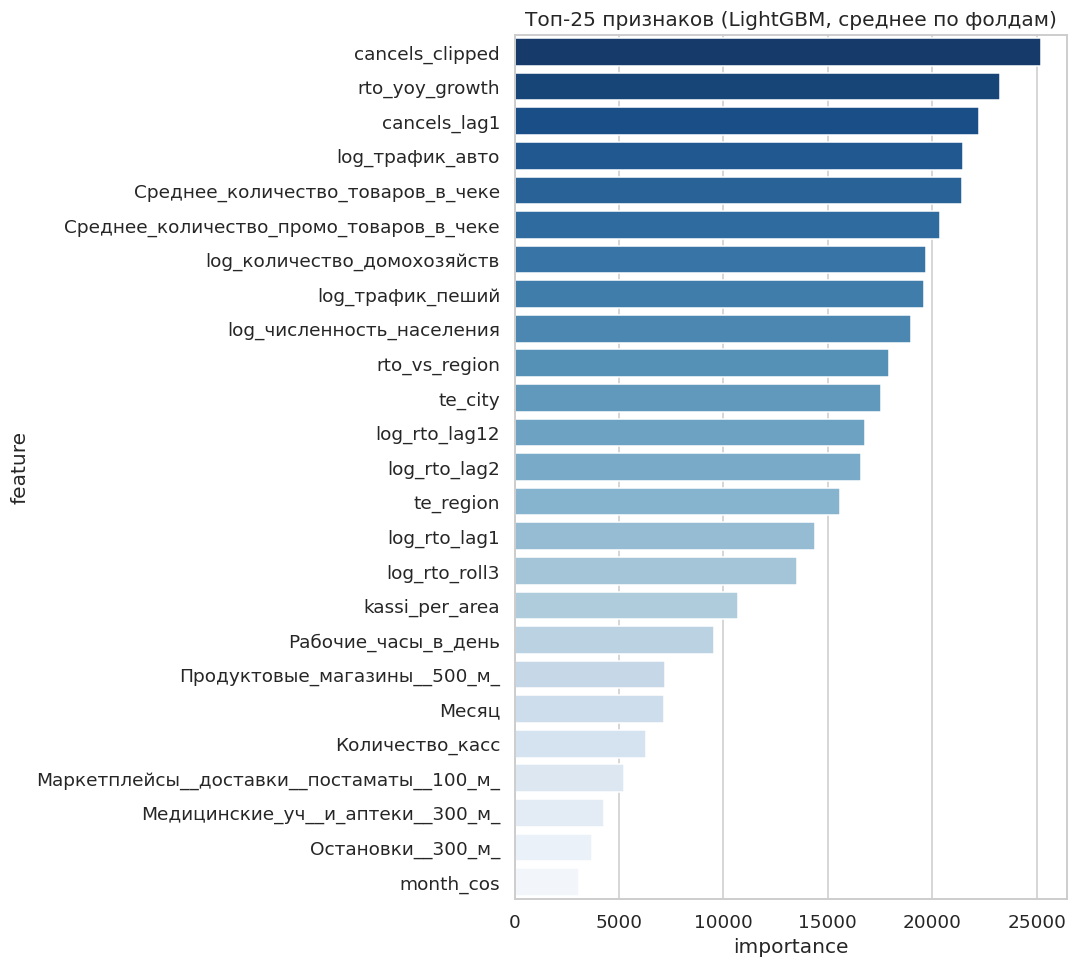


Топ-10 признаков:
                                feature  importance
                        cancels_clipped     25212.6
                         rto_yoy_growth     23256.8
                           cancels_lag1     22226.6
                        log_трафик_авто     21453.2
      Среднее_количество_товаров_в_чеке     21415.6
Среднее_количество_промо_товаров_в_чеке     20364.8
            log_количество_домохозяйств     19683.6
                       log_трафик_пеший     19611.2
              log_численность_населения     18959.8
                          rto_vs_region     17909.4


In [16]:
importances = np.mean([m.feature_importances_ for m in lgb_models], axis=0)
imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=imp_df.head(25), x='importance', y='feature', ax=ax, palette='Blues_r')
ax.set_title('Топ-25 признаков (LightGBM, среднее по фолдам)')
plt.tight_layout()
plt.show()

print("\nТоп-10 признаков:")
print(imp_df.head(10)[['feature', 'importance']].to_string(index=False))

## 12. Предсказание РТО — март 2025

Применяем тот же FE-пайплайн к целевому периоду.
Lag-признак (отмены) берётся из февраля 2025.


In [17]:
# FE на тестовом периоде — lag_source содержит февраль 2025 (наш таргет)
# Объединяем train + feb_2025 как источник лагов
lag_source_full = pd.concat([df_train_raw, feb_2025], ignore_index=True)

df_test_fe = feature_engineering(df_target_raw, lag_source=lag_source_full, is_train=False)

df_test_fe['te_region'] = target_encode_transform(
    df_test_fe['Регион'], te_region_groups, te_region_mean)
df_test_fe['te_city'] = target_encode_transform(
    df_test_fe['Населенный пункт'], te_city_groups, te_city_mean)

df_test_fe = clean_col_names(df_test_fe)

missing_test = [f for f in FEATURES if f not in df_test_fe.columns]
if missing_test:
    print(f"⚠️ Отсутствуют: {missing_test}")
else:
    print("Все признаки на месте ✓")

X_test = df_test_fe[FEATURES]
print(f"Тестовая выборка: {X_test.shape}")

Все признаки на месте ✓
Тестовая выборка: (18657, 34)


In [18]:
# Предсказываем — среднее по фолдам для каждой модели
lgb_test = np.mean([m.predict(X_test) for m in lgb_models], axis=0)
xgb_test = np.mean([m.predict(X_test) for m in xgb_models], axis=0)
cat_test = np.mean([m.predict(X_test) for m in cat_models], axis=0)

log_pred = WEIGHTS[0]*lgb_test + WEIGHTS[1]*xgb_test + WEIGHTS[2]*cat_test
rto_pred = np.expm1(log_pred)

df_result = df_target_raw[['new_id', 'Год', 'Месяц', 'Регион', 'Населенный пункт']].copy()
df_result['РТО_прогноз'] = rto_pred

print(f"Предсказано магазинов: {len(df_result)}")
print(f"Среднее РТО (март 2025):  {rto_pred.mean():,.0f}")
print(f"Медианное РТО (март 2025): {np.median(rto_pred):,.0f}")
df_result.head(10)

Предсказано магазинов: 18657
Среднее РТО (март 2025):  100,676,385
Медианное РТО (март 2025): 87,888,570


,new_id,Год,Месяц,Регион,Населенный пункт,РТО_прогноз
3,0,2025,3,Ярославская обл,Ярославль г,9.281639e+07
31,1,2025,3,Челябинская обл,Магнитогорск г,4.422204e+07
57,2,2025,3,Татарстан Респ,Казань г,8.806432e+07
81,3,2025,3,Самарская обл,Подбельск с,6.774298e+07
108,4,2025,3,Калужская обл,Калуга г,8.246475e+07
134,5,2025,3,Брянская обл,Брянск г,7.657939e+07
161,6,2025,3,Краснодарский край,Краснодар г,1.664497e+08
185,7,2025,3,Кировская обл,Нагорск пгт,8.071687e+07
212,8,2025,3,Московская обл,Малаховка пгт.,2.320192e+08
237,9,2025,3,Ростовская обл,Батайск г,5.434468e+07


## 13. Визуализация прогнозов

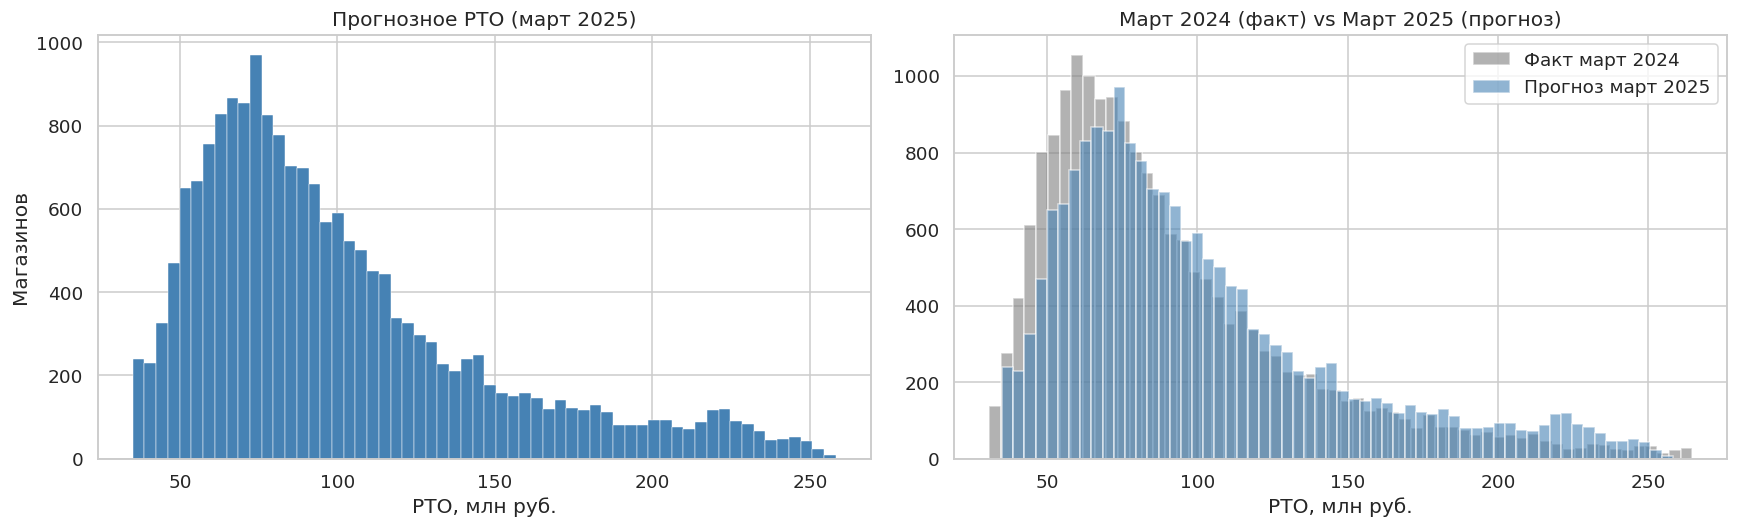

Март 2024 медиана (факт):    78.9 млн
Март 2025 медиана (прогноз): 87.9 млн
YoY рост:                    11.3%


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Распределение прогноза
axes[0].hist(rto_pred / 1e6, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Прогнозное РТО (март 2025)')
axes[0].set_xlabel('РТО, млн руб.')
axes[0].set_ylabel('Магазинов')

# Факт март 2024 vs прогноз март 2025
mar_2024 = df_train_raw[(df_train_raw['Год'] == 2024) & (df_train_raw['Месяц'] == 3)]['РТО']
axes[1].hist(mar_2024 / 1e6, bins=60, alpha=0.6, color='gray', edgecolor='white', label='Факт март 2024')
axes[1].hist(rto_pred / 1e6, bins=60, alpha=0.6, color='steelblue', edgecolor='white', label='Прогноз март 2025')
axes[1].set_title('Март 2024 (факт) vs Март 2025 (прогноз)')
axes[1].set_xlabel('РТО, млн руб.')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Март 2024 медиана (факт):    {mar_2024.median()/1e6:.1f} млн")
print(f"Март 2025 медиана (прогноз): {np.median(rto_pred)/1e6:.1f} млн")
print(f"YoY рост:                    {(np.median(rto_pred)/mar_2024.median()-1)*100:.1f}%")

## 15. Сохранение результатов

In [20]:
print("\nТоп-10 магазинов по прогнозу:")
display(df_result.nlargest(10, 'РТО_прогноз')
        .assign(млн=lambda x: (x['РТО_прогноз']/1e6).round(2))
        [['new_id', 'Регион', 'Населенный пункт', 'млн']])


Топ-10 магазинов по прогнозу:


,new_id,Регион,Населенный пункт,млн
42878,1938,Москва г,Москва г,258.22
182185,8196,Московская обл,Видное г,256.75
286003,12846,Москва г,Москва г,256.51
245210,11013,Московская обл,Одинцово г,255.77
364265,16329,Московская обл,Химки г,255.48
257663,11579,Москва г,Москва г,255.43
308937,13845,Москва г,Москва г,255.16
184630,8301,Москва г,Москва г,254.83
437687,19606,Москва г,Москва г,254.43
137335,6177,Московская обл,Красногорск г,254.30


In [21]:
submit = pd.DataFrame({
    'new_id': df_result['new_id'],
    'rto': df_result['РТО_прогноз']
    })
submit.to_csv('test.csv', index=False)

In [22]:
print(f"Нулей в lgb_oof: {(lgb_oof == 0).sum()}")

Нулей в lgb_oof: 39696
